In [22]:
# Importing required librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
# Load the dataset
df=pd.read_csv("1) iris.csv")

In [24]:
#  Displaying Entire data
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [25]:
# Dataset shape
df.shape

(150, 5)

In [26]:
# Dataset statistical summary
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [27]:
# First 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
# Last 5 rows
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [29]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [30]:
# Checking Null values
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [31]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [32]:
# As the data set has no null values let us check for duplicates
# Checking Duplicate Rows
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [33]:
df.duplicated().sum()

np.int64(3)

In [34]:
print("Before removing duplicates:",df.shape)

Before removing duplicates: (150, 5)


In [35]:
# As the data has 3 duplicate rows let us remove those
# Removing duplicates
df=df.drop_duplicates()

In [36]:
df.duplicated().sum()

np.int64(0)

In [38]:
print("After removing dupliactes:",df.shape)

After removing dupliactes: (147, 5)


In [39]:
print("Remaining duplicate rows:",df.duplicated().sum())

Remaining duplicate rows: 0


In [40]:
# Checking the datatypes
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [42]:
# Checking Unique species
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [44]:
# Checking how many records belong to each species
df["species"].value_counts()

species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

In [45]:
# Check for invalid numerical values
numeric_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]
for column in numeric_columns:
    print(f"\n{column}")
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


sepal_length
Minimum: 4.3
Maximum: 7.9

sepal_width
Minimum: 2.0
Maximum: 4.4

petal_length
Minimum: 1.0
Maximum: 6.9

petal_width
Minimum: 0.1
Maximum: 2.5


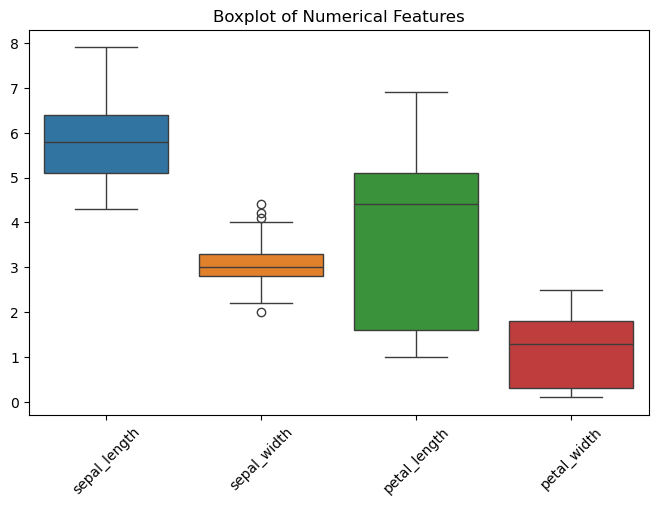

In [46]:
# Visualize the data before preprocessing
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[numeric_columns])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

In [47]:
# Encode the target column
label_encoder = LabelEncoder()
df["species_encoded"] = label_encoder.fit_transform(df["species"])
df.head()

/var/folders/xv/bfj5tcfx571g97g06kpcqr1r0000gn/T/ipykernel_1953/4038527600.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["species_encoded"] = label_encoder.fit_transform(df["species"])


,sepal_length,sepal_width,petal_length,petal_width,species,species_encoded
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [48]:
# Check the mapping
mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))
print(mapping)

{'setosa': np.int64(0), 'versicolor': np.int64(1), 'virginica': np.int64(2)}


In [49]:
# Separate features and target
X = df[numeric_columns]
y = df["species_encoded"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (147, 4)
Target shape: (147,)


In [50]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=numeric_columns
)
X_scaled.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.915509,1.019971,-1.357737,-1.3357
1,-1.157560,-0.128082,-1.357737,-1.3357
2,-1.399610,0.331139,-1.414778,-1.3357
3,-1.520635,0.101529,-1.300696,-1.3357
4,-1.036535,1.249582,-1.357737,-1.3357


In [51]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (117, 4)
Testing data: (30, 4)


In [52]:
# Final Dataset check
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nFinal columns:")
print(df.columns)

Final dataset shape: (147, 6)

Missing values:
sepal_length       0
sepal_width        0
petal_length       0
petal_width        0
species            0
species_encoded    0
dtype: int64

Duplicate rows:
0

Final columns:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species',
       'species_encoded'],
      dtype='object')


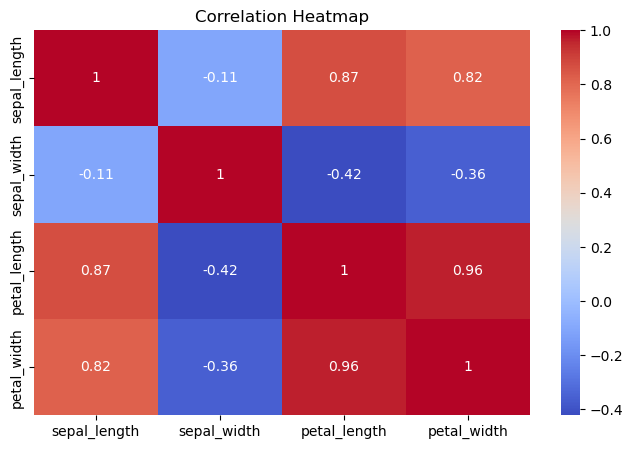

In [53]:
# Correlation Heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [54]:
# Final Cleaned Dataset
df.to_csv("iris_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
## Conclusion

In this task, the Iris dataset was successfully cleaned and preprocessed.

The following steps were performed:

1. Loaded and inspected the dataset.
2. Checked the structure and data types.
3. Checked for missing values.
4. Identified and removed duplicate rows.
5. Checked categorical values and numerical features.
6. Encoded the target variable using Label Encoding.
7. Separated features and target variables.
8. Standardized numerical features using StandardScaler.
9. Split the dataset into training and testing sets.
10. Visualized the numerical features and their correlations.

The final dataset is now clean and ready to be used for machine learning.